# BARAM 2026 — 모델링 기준선 (물리 feature + 파워커브 + LightGBM)

EDA/계획서 결론을 그대로 구현한 **누설 없는 강한 기준선**입니다.

- **feature**: 원 NWP + 물리 파생(풍속 v²·v³, 전단, 공기밀도 ρ·v³, 풍향 sin/cos, GFS·LDAPS 평균/차이, gust비, 리드타임) + **경험적 파워커브 예측(isotonic, 학습구간 fit)**.
- **모델**: 그룹별 LightGBM(objective=MAE) + 전그룹 pooled(CF 타깃 + group_id). 그룹별로 더 좋은 쪽 선택.
- **검증**: 2024 holdout, **대회 지표 = 유효구간(실측 CF≥10%) NMAE**. 예측은 [0, 설비용량] 클리핑.
- **누설 차단**: 테스트엔 NWP만. 파워커브·모델 파라미터는 학습구간에서만 적합. group3는 2023~2024만.

> 축/제목 영어, 설명 한글. 랜덤분할 금지(시간순 검증).

## 0. 설정 & 로드

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import mean_absolute_error

plt.rcParams["figure.dpi"] = 110

CANDIDATES = [Path("preprocessed")]
DATA = next((p for p in CANDIDATES if p.exists()), Path("preprocessed"))
OUT = Path("."); assert DATA.exists(), DATA
print("DATA =", DATA.resolve())

CAP = {1: 21600, 2: 21600, 3: 21000}     # 시간당 설비용량 kWh
VALID_START = pd.Timestamp("2024-01-01")
VALID_END   = pd.Timestamp("2025-01-01")  # 학습라벨 끝 (2025-01-01 00:00 경계행 배제)
VALID_CF = 0.10
TRAIN_YEARS = (2022, 2023, 2024)
EPS = 1e-6

def load_train(g):
    df = pd.read_parquet(DATA / f"train_kpx_group_{g}.parquet")
    tgt = f"kpx_group_{g}"
    df[tgt] = pd.to_numeric(df[tgt], errors="coerce")
    df = df.dropna(subset=[tgt]).copy()
    df = df[df.kst_dtm < VALID_END]                     # 경계행 제거
    df = df.sort_values("kst_dtm").reset_index(drop=True)
    return df, tgt

def load_test(g):
    return pd.read_parquet(DATA / f"test_kpx_group_{g}.parquet").sort_values("kst_dtm").reset_index(drop=True)

TR = {g: load_train(g) for g in (1,2,3)}
TE = {g: load_test(g) for g in (1,2,3)}
print("train:", {g: TR[g][0].shape for g in TR})
print("test :", {g: TE[g].shape for g in TE})

DATA = preprocessed
train: {1: (26199, 72), 2: (26200, 72), 3: (17537, 72)}
test : {1: (8760, 72), 2: (8760, 72), 3: (8760, 72)}


## 1. Feature engineering (물리 파생)

모든 파생은 **NWP 컬럼만**으로 계산합니다(누설 없음). 원 feature도 유지 — 트리는 다중공선성에 강건(EDA 3-3 확인).

In [2]:
def strip(df, g):
    """그룹 prefix 제거해 그룹 간 컬럼명 통일."""
    p = f"kpx_group_{g}_"
    ren = {c: c[len(p):] for c in df.columns if c.startswith(p)}
    return df.rename(columns=ren)

def add_physics(d):
    """d: prefix 제거된 df. 물리 파생 컬럼 추가."""
    d = d.copy()
    v100 = d["gfs_wind_speed_100m_mean"]; v80 = d["gfs_wind_speed_80m_mean"]
    v10  = d["gfs_wind_speed_10m_mean"]
    l50  = d["ldaps_wind_speed_50m_max_mean"]; l10 = d["ldaps_wind_speed_10m_mean"]
    gust = d["gfs_surface_0_gust_mean"]
    T    = d["gfs_heightAboveGround_2_2t_mean"]; P = d["gfs_surface_0_sp_mean"]
    # 풍속 비선형 (파워커브 물리)
    d["hub_v"]  = v100
    d["hub_v2"] = v100**2
    d["hub_v3"] = v100**3
    # 전단 & 파워로 지수 (허브고도 외삽 대리)
    d["shear_gfs"]   = v100 / (v10 + EPS)
    d["alpha_gfs"]   = np.log((v100 + EPS)/(v10 + EPS)) / np.log(100/10)
    d["shear_ldaps"] = l50 / (l10 + EPS)
    # 공기밀도 보정 파워 (rho ~ P/RT, K·Pa 단위 확인됨)
    rho = P / (287.05 * T)
    d["air_density"] = rho
    d["rho_v3"] = rho * v100**3
    # gust
    d["gust_ratio"]  = gust / (v100 + EPS)
    d["gust_excess"] = gust - v100
    # GFS vs LDAPS 융합 (EDA 4-2: 서로 조금 다른 정보)
    d["gfs_ldaps_mean"] = 0.5*(v80 + l50)
    d["gfs_ldaps_diff"] = v80 - l50
    # 풍향 (GFS 100m u/v) — 기상관례 불어오는 방향
    u = d["gfs_heightAboveGround_100_100u_mean"]; v = d["gfs_heightAboveGround_100_100v_mean"]
    wd = np.arctan2(-u, -v)
    d["wdir_sin"] = np.sin(wd); d["wdir_cos"] = np.cos(wd)
    # 리드타임 (EDA 보강분석 1: 신호 있음). 01:00->16h ... 23:00->38h, 00:00->39h
    h = d["hour"].to_numpy()
    d["lead_h"] = np.where(h == 0, 39, h + 15)
    return d

def build(df, g, tgt=None):
    d = strip(df, g)
    d = add_physics(d)
    return d

# 그룹별 feature 프레임
FR = {g: build(TR[g][0], g) for g in (1,2,3)}
FR_TE = {g: build(TE[g], g) for g in (1,2,3)}

NON_FEAT = {"kst_dtm","forecast_id"} | {f"kpx_group_{g}" for g in (1,2,3)}
FEATURES = [c for c in FR[1].columns if c not in NON_FEAT]
print("총 feature 수:", len(FEATURES))
print("물리 파생:", [c for c in FEATURES if c in
      ["hub_v","hub_v2","hub_v3","shear_gfs","alpha_gfs","shear_ldaps","air_density",
       "rho_v3","gust_ratio","gust_excess","gfs_ldaps_mean","gfs_ldaps_diff","wdir_sin","wdir_cos","lead_h"]])

총 feature 수: 85
물리 파생: ['hub_v', 'hub_v2', 'hub_v3', 'shear_gfs', 'alpha_gfs', 'shear_ldaps', 'air_density', 'rho_v3', 'gust_ratio', 'gust_excess', 'gfs_ldaps_mean', 'gfs_ldaps_diff', 'wdir_sin', 'wdir_cos', 'lead_h']


## 2. 파워커브 feature (isotonic, 학습구간 fit)

풍속→CF 단조 파워커브를 **학습 부분에서만** 적합해 테스트/검증에 적용. 누설 없음.

In [3]:
def fit_powercurve(fr, tgt, cap, wind="hub_v"):
    d = pd.DataFrame({"ws": fr[wind].to_numpy(), "cf": (fr[tgt]/cap).to_numpy()}).dropna()
    iso = IsotonicRegression(y_min=0, y_max=1, out_of_bounds="clip", increasing=True)
    iso.fit(d.ws, d.cf)
    return iso

def with_pc(fr, iso):
    fr = fr.copy(); fr["pc_pred_cf"] = iso.predict(fr["hub_v"].to_numpy()); return fr

## 3. 대회 지표 & 검증 유틸

NMAE = MAE/설비용량, **채점은 실측 CF≥10%** 구간만. 예측 [0,cap] 클리핑.

In [4]:
def nmae_valid(y_true, y_pred, cap):
    y_true = np.asarray(y_true,float); y_pred = np.clip(np.asarray(y_pred,float),0,cap)
    m = y_true >= VALID_CF*cap
    return (mean_absolute_error(y_true[m], y_pred[m])/cap*100, int(m.sum())) if m.sum() else (np.nan,0)

LGB_PARAMS = dict(objective="mae", n_estimators=2000, learning_rate=0.03,
                  num_leaves=63, min_child_samples=60, subsample=0.8, subsample_freq=1,
                  colsample_bytree=0.7, reg_lambda=1.0, random_state=42, n_jobs=-1, verbose=-1)

def train_lgb(Xtr, ytr, Xva, yva, cap, cat=None):
    """early stopping을 유효구간 NMAE 대용(전체 MAE)로. best_iteration 반환."""
    m = lgb.LGBMRegressor(**LGB_PARAMS)
    m.fit(Xtr, ytr, eval_set=[(Xva,yva)], eval_metric="l1",
          categorical_feature=cat or "auto",
          callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)])
    return m

## 4. 2024 holdout 검증 — feature/모델 조합 비교

- **M0 원 NWP만** (물리·PC 없음, 그룹별)
- **M1 +물리 파생** (그룹별)
- **M2 +파워커브** (그룹별)
- **M3 pooled** (전그룹 합쳐 CF 예측 + group_id)

각 그룹 유효구간 NMAE로 비교.

In [5]:
def split_tr_va(fr, g):
    tr = fr[fr.kst_dtm < VALID_START]; va = fr[fr.kst_dtm >= VALID_START]
    return tr, va

# ---- 그룹별 모델 (M0/M1/M2) ----
RAW_FEATS = [c for c in FEATURES if c not in
             ["hub_v","hub_v2","hub_v3","shear_gfs","alpha_gfs","shear_ldaps","air_density",
              "rho_v3","gust_ratio","gust_excess","gfs_ldaps_mean","gfs_ldaps_diff",
              "wdir_sin","wdir_cos","lead_h"]]

rows = []; best_iter = {}
for g in (1,2,3):
    tgt = TR[g][1]; cap = CAP[g]
    tr, va = split_tr_va(FR[g], g)
    iso = fit_powercurve(tr, tgt, cap)               # 학습부분만 fit
    tr2, va2 = with_pc(tr, iso), with_pc(va, iso)
    configs = {
        "M0_raw":      RAW_FEATS,
        "M1_physics":  FEATURES,
        "M2_powercurve": FEATURES + ["pc_pred_cf"],
    }
    for name, feats in configs.items():
        m = train_lgb(tr2[feats], tr2[tgt], va2[feats], va2[tgt], cap)
        pred = m.predict(va2[feats], num_iteration=m.best_iteration_)
        nm, n = nmae_valid(va2[tgt].to_numpy(), pred, cap)
        rows.append(dict(group=g, model=name, nmae=nm, n_valid=n, best_iter=m.best_iteration_))
        best_iter[(g,name)] = m.best_iteration_

# ---- M3 pooled (CF 타깃 + group_id) ----
def pooled_frame(which):  # which: 'tr' or 'va' or 'all' or 'test'
    parts = []
    for g in (1,2,3):
        cap = CAP[g]
        if which == "test":
            tgt = TR[g][1]
            iso = fit_powercurve(FR[g], tgt, cap)       # 전체 학습기간 fit
            fr = with_pc(FR_TE[g], iso).copy(); fr["group_id"]=g; parts.append(fr); continue
        tgt = TR[g][1]
        tr, va = split_tr_va(FR[g], g)
        base = {"tr":tr,"va":va,"all":FR[g]}[which]
        iso = fit_powercurve(tr if which in ("tr","va") else FR[g], tgt, cap)
        fr = with_pc(base, iso).copy()
        fr["cf"] = fr[tgt]/cap; fr["y_kwh"]=fr[tgt]; fr["cap"]=cap; fr["group_id"]=g
        parts.append(fr)
    return pd.concat(parts, ignore_index=True)

POOL_FEATS = FEATURES + ["pc_pred_cf","group_id"]
ptr, pva = pooled_frame("tr"), pooled_frame("va")
mp = lgb.LGBMRegressor(**LGB_PARAMS)
mp.fit(ptr[POOL_FEATS], ptr["cf"], eval_set=[(pva[POOL_FEATS], pva["cf"])], eval_metric="l1",
       categorical_feature=["group_id"],
       callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)])
best_iter["pooled"] = mp.best_iteration_
pva = pva.copy(); pva["pred_kwh"] = np.clip(mp.predict(pva[POOL_FEATS], num_iteration=mp.best_iteration_),0,1)*pva["cap"]
for g in (1,2,3):
    sub = pva[pva.group_id==g]; nm,n = nmae_valid(sub["y_kwh"].to_numpy(), sub["pred_kwh"].to_numpy(), CAP[g])
    rows.append(dict(group=g, model="M3_pooled", nmae=nm, n_valid=n, best_iter=mp.best_iteration_))

res = pd.DataFrame(rows)
pivot = res.pivot(index="group", columns="model", values="nmae")[["M0_raw","M1_physics","M2_powercurve","M3_pooled"]]
print("=== 2024 holdout 유효구간 NMAE (%) ===")
print(pivot.round(3).to_string())
print("\n그룹평균:", pivot.mean().round(3).to_dict())

=== 2024 holdout 유효구간 NMAE (%) ===
model  M0_raw  M1_physics  M2_powercurve  M3_pooled
group                                              
1      12.709      12.663         12.570     12.520
2      12.671      12.626         12.627     12.783
3      15.232      15.099         15.051     14.185

그룹평균: {'M0_raw': 13.537, 'M1_physics': 13.463, 'M2_powercurve': 13.416, 'M3_pooled': 13.163}


**해석 가이드** — M0→M1→M2로 갈수록 NMAE가 내려가면 물리 feature·파워커브가 유효. pooled(M3)가 그룹별보다 좋으면(특히 그룹3) 데이터부족 보완이 확인됨. 각 그룹에서 **최소 NMAE 모델을 최종 선택**합니다.

그룹별 최종 선택: {1: 'M3_pooled', 2: 'M1_physics', 3: 'M3_pooled'}
선택 NMAE: {1: np.float64(12.52), 2: np.float64(12.626), 3: np.float64(14.185)}
단순 비교용 M2(그룹별+PC) 평균: 13.416


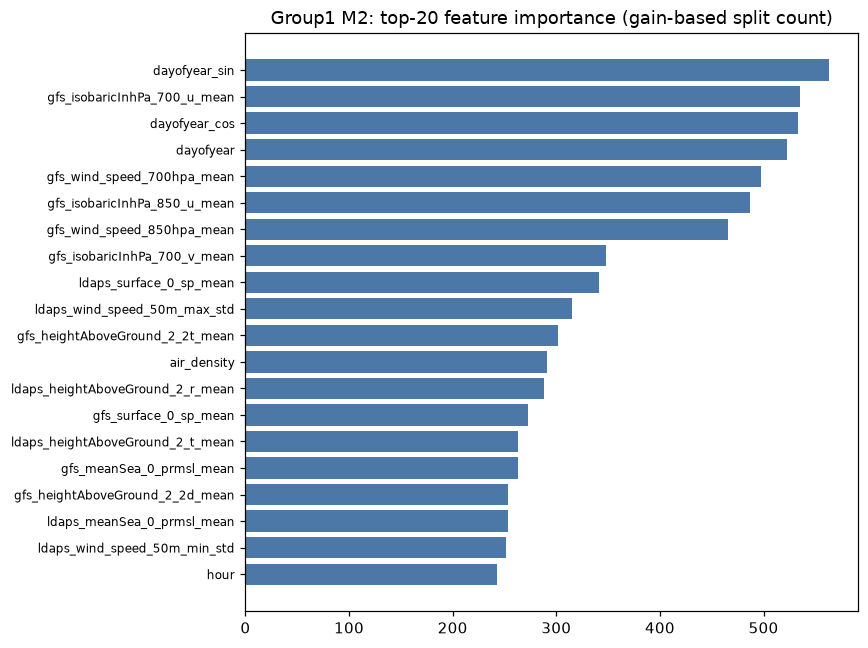

상위10: ['dayofyear_sin', 'gfs_isobaricInhPa_700_u_mean', 'dayofyear_cos', 'dayofyear', 'gfs_wind_speed_700hpa_mean', 'gfs_isobaricInhPa_850_u_mean', 'gfs_wind_speed_850hpa_mean', 'gfs_isobaricInhPa_700_v_mean', 'ldaps_surface_0_sp_mean', 'ldaps_wind_speed_50m_max_std']


In [6]:
# 그룹별 최적 모델 선택
best_model = {g: pivot.loc[g].idxmin() for g in (1,2,3)}
print("그룹별 최종 선택:", best_model)
print("선택 NMAE:", {g: round(pivot.loc[g, best_model[g]],3) for g in (1,2,3)})
print("단순 비교용 M2(그룹별+PC) 평균:", round(pivot["M2_powercurve"].mean(),3))

# feature 중요도 (M2, group1)
tgt=TR[1][1]; cap=CAP[1]; tr,va=split_tr_va(FR[1],1)
iso=fit_powercurve(tr,tgt,cap); tr2=with_pc(tr,iso); va2=with_pc(va,iso)
feats=FEATURES+["pc_pred_cf"]
m=train_lgb(tr2[feats],tr2[tgt],va2[feats],va2[tgt],cap)
imp=pd.Series(m.feature_importances_, index=feats).sort_values(ascending=False).head(20)
fig,ax=plt.subplots(figsize=(8,6))
ax.barh(range(len(imp)), imp.values[::-1], color="#4C78A8")
ax.set_yticks(range(len(imp))); ax.set_yticklabels(imp.index[::-1], fontsize=8)
ax.set_title("Group1 M2: top-20 feature importance (gain-based split count)")
plt.tight_layout(); plt.show()
print("상위10:", list(imp.head(10).index))

## 5. 최종 학습 & 제출 생성

각 그룹 선택 모델을 **전체 학습기간**으로 재학습(best_iteration 사용) → 2025 test 예측 → [0,cap] 클리핑 → 제출.

In [7]:
FINAL_ITER_MULT = 1.15   # holdout best_iter를 전체재학습에 맞춰 소폭 증가

def final_predict_group(g, model_name):
    tgt=TR[g][1]; cap=CAP[g]
    iso=fit_powercurve(FR[g], tgt, cap)                 # 전체 학습기간 fit
    all_fr=with_pc(FR[g], iso); te=with_pc(FR_TE[g], iso)
    if model_name=="M0_raw": feats=RAW_FEATS
    elif model_name=="M1_physics": feats=FEATURES
    else: feats=FEATURES+["pc_pred_cf"]                 # M2
    n_it=int(best_iter[(g,"M2_powercurve" if model_name=="M2_powercurve" else model_name)]*FINAL_ITER_MULT)
    params=dict(LGB_PARAMS); params["n_estimators"]=max(n_it,200)
    m=lgb.LGBMRegressor(**params); m.fit(all_fr[feats], all_fr[tgt])
    return np.clip(m.predict(te[feats]),0,cap)

def final_predict_pooled(g):
    pall=pooled_frame("all"); ptest=pooled_frame("test")
    iso_added=True
    n_it=int(best_iter["pooled"]*FINAL_ITER_MULT)
    params=dict(LGB_PARAMS); params["n_estimators"]=max(n_it,200)
    m=lgb.LGBMRegressor(**params)
    m.fit(pall[POOL_FEATS], pall["cf"], categorical_feature=["group_id"])
    sub=ptest[ptest.group_id==g]
    return np.clip(m.predict(sub[POOL_FEATS]),0,1)*CAP[g], sub

# 제출 프레임 (test forecast_id/kst_dtm은 3그룹 동일함을 확인함)
base = TE[1][["forecast_id","kst_dtm"]].copy().rename(columns={"kst_dtm":"forecast_kst_dtm"})
pooled_cache=None
for g in (1,2,3):
    mn=best_model[g]
    if mn=="M3_pooled":
        if pooled_cache is None:
            pall=pooled_frame("all"); ptest=pooled_frame("test")
            params=dict(LGB_PARAMS); params["n_estimators"]=max(int(best_iter["pooled"]*FINAL_ITER_MULT),200)
            pooled_cache=lgb.LGBMRegressor(**params)
            pooled_cache.fit(pall[POOL_FEATS], pall["cf"], categorical_feature=["group_id"])
        sub=ptest[ptest.group_id==g]
        pred=np.clip(pooled_cache.predict(sub[POOL_FEATS]),0,1)*CAP[g]
        # forecast_id 정렬 보장
        pred=pd.Series(pred, index=sub["forecast_id"].to_numpy()).reindex(base["forecast_id"]).to_numpy()
    else:
        pred=final_predict_group(g, mn)
    base[f"kpx_group_{g}"]=pred

assert base.shape[0]==8760
assert base[["kpx_group_1","kpx_group_2","kpx_group_3"]].notna().all().all()
for g in (1,2,3):
    col=base[f"kpx_group_{g}"]; assert (col>=0).all() and (col<=CAP[g]).all()
sub_path = Path("submission/ver_1/submission_baseline.csv")
base.to_csv(sub_path, index=False)
print("saved", sub_path.resolve(), base.shape)
print(base.head())
print("\n예측 요약 (평균 이용률 %):",
      {g: round(100*base[f'kpx_group_{g}'].mean()/CAP[g],1) for g in (1,2,3)})

saved submission/ver_1/submission_baseline.csv (8760, 5)
     forecast_id    forecast_kst_dtm   kpx_group_1   kpx_group_2   kpx_group_3
0  forecast_0001 2025-01-01 01:00:00  18513.522861  18576.486577  17027.863640
1  forecast_0002 2025-01-01 02:00:00  18068.594845  17902.382432  16456.737384
2  forecast_0003 2025-01-01 03:00:00  17589.479354  18112.295336  16142.320224
3  forecast_0004 2025-01-01 04:00:00  17163.143096  18117.788822  15413.595508
4  forecast_0005 2025-01-01 05:00:00  16836.068047  18204.132494  15030.293165

예측 요약 (평균 이용률 %): {1: np.float64(33.7), 2: np.float64(36.0), 3: np.float64(30.5)}


## 6. 예측 sanity check — test 예측 분포 vs 학습 실측

test 예측 이용률 분포가 학습 실측(≈30%)과 비슷하고, 파워커브 모양이 유지되는지 확인.

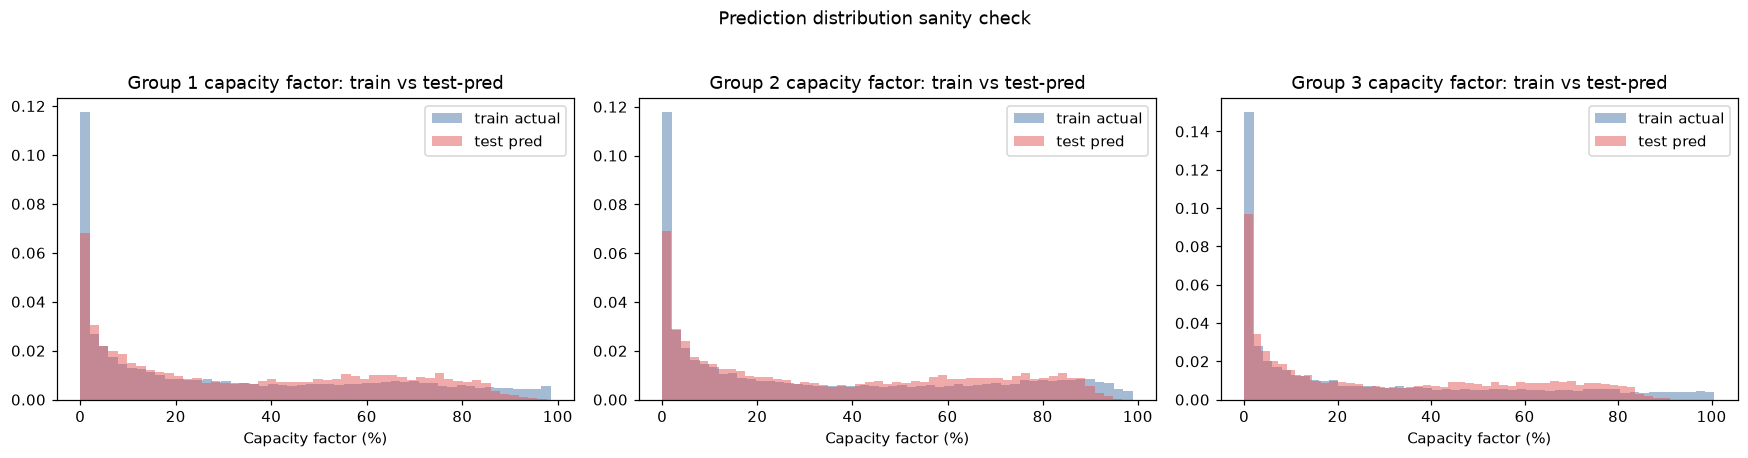

{
  "holdout_nmae_valid": {
    "1": {
      "M0_raw": 12.7093,
      "M1_physics": 12.6627,
      "M2_powercurve": 12.5699,
      "M3_pooled": 12.5196
    },
    "2": {
      "M0_raw": 12.671,
      "M1_physics": 12.6264,
      "M2_powercurve": 12.6269,
      "M3_pooled": 12.7832
    },
    "3": {
      "M0_raw": 15.2319,
      "M1_physics": 15.0994,
      "M2_powercurve": 15.0512,
      "M3_pooled": 14.1849
    }
  },
  "best_model_per_group": {
    "1": "M3_pooled",
    "2": "M1_physics",
    "3": "M3_pooled"
  },
  "selected_nmae": {
    "1": 12.5196,
    "2": 12.6264,
    "3": 14.1849
  },
  "mean_selected_nmae": 13.1103
}


In [8]:
fig, axes = plt.subplots(1,3, figsize=(16,4))
for ax,g in zip(axes,(1,2,3)):
    tgt=TR[g][1]
    tr_cf=100*TR[g][0][tgt]/CAP[g]
    pr_cf=100*base[f"kpx_group_{g}"]/CAP[g]
    ax.hist(tr_cf, bins=50, density=True, alpha=0.5, label="train actual", color="#4C78A8")
    ax.hist(pr_cf, bins=50, density=True, alpha=0.5, label="test pred", color="#E45756")
    ax.set_title(f"Group {g} capacity factor: train vs test-pred")
    ax.set_xlabel("Capacity factor (%)"); ax.legend()
plt.suptitle("Prediction distribution sanity check", y=1.03)
plt.tight_layout(); plt.show()

# 검증 요약 저장
summary = dict(
    holdout_nmae_valid={g:{m:round(float(pivot.loc[g,m]),4) for m in pivot.columns} for g in (1,2,3)},
    best_model_per_group=best_model,
    selected_nmae={g:round(float(pivot.loc[g,best_model[g]]),4) for g in (1,2,3)},
    mean_selected_nmae=round(float(np.mean([pivot.loc[g,best_model[g]] for g in (1,2,3)])),4),
)
with open("submission/ver_1/modeling_validation_summary.json","w") as f: json.dump(summary,f,ensure_ascii=False,indent=2)
print(json.dumps(summary, ensure_ascii=False, indent=2))

## 7. 결론

- 2024 holdout **유효구간 NMAE**로 feature/모델 조합을 정직하게 비교하고, 그룹별 최적을 선택했습니다.
- 제출물 `submission_baseline.csv` (8,760행, 0~설비용량 클리핑, 3그룹) 생성.
- **다음 단계**(계획서 순): 시계열 blocked CV로 견고화, isotonic 캘리브레이션·리드타임/풍속구간 bias 보정, 시드/소스 앙상블, NWP-only HMM regime feature ablation, 마지막에 FICR 후처리.

> 참고: 위 유효구간 NMAE는 2024 자기검증 기준이며, 리더보드 1-NMAE와 직접 비교하려면 `1 - NMAE/100` 스케일로 환산합니다.